# Classifier

In this notebook the part of the Street-Sign model, that classifies the Streetsigns including the region code, is created and trained

## Create crops from training images
images are from Mapillary traffic sign dataset

In [3]:
import os
import json
from PIL import Image
import shutil

# Paths
images_folder = "dataset/images/train"
json_folder = "annotations/train"
crops_folder = "crops_per_label"

os.makedirs(crops_folder, exist_ok=True)

# Function to crop objects based on JSON annotations
def crop_objects_from_image(image_path, json_path, save_root):
    with open(json_path, "r") as f:
        data = json.load(f)

    image = Image.open(image_path)
    base_name = os.path.splitext(os.path.basename(image_path))[0]

    for obj in data.get("objects", []):
        label = obj["label"]
        bbox = obj["bbox"]
        xmin = int(bbox["xmin"])
        ymin = int(bbox["ymin"])
        xmax = int(bbox["xmax"])
        ymax = int(bbox["ymax"])

        cropped = image.crop((xmin, ymin, xmax, ymax))

        label_folder = os.path.join(save_root, label)
        os.makedirs(label_folder, exist_ok=True)

        crop_filename = f"{base_name}_{obj['key']}.png"
        crop_path = os.path.join(label_folder, crop_filename)
        cropped.save(crop_path)
        print(f"Saved crop: {crop_path}")

# Match images and JSON files and crop
image_files = [f for f in os.listdir(images_folder) if os.path.isfile(os.path.join(images_folder, f))]
json_files = {os.path.splitext(f)[0]: f for f in os.listdir(json_folder) if f.lower().endswith(".json")}

for img_file in image_files:
    img_name = os.path.splitext(img_file)[0]
    if img_name in json_files:
        img_path = os.path.join(images_folder, img_file)
        json_path = os.path.join(json_folder, json_files[img_name])
        crop_objects_from_image(img_path, json_path, crops_folder)

print("All crops done!")


Saved crop: crops_per_label\other-sign\--vWKSR3Rh8quTfK4AuKOQ_tr64yft61b73dudyjix53j.png
Saved crop: crops_per_label\other-sign\--vWKSR3Rh8quTfK4AuKOQ_df6ax8buw8ymu7iki2crt1.png
Saved crop: crops_per_label\other-sign\--vWKSR3Rh8quTfK4AuKOQ_zsmon3y9mlwtupmaulih0d.png
Saved crop: crops_per_label\other-sign\--vWKSR3Rh8quTfK4AuKOQ_g78zslajz2bow2w1b09yns.png
Saved crop: crops_per_label\other-sign\--vWKSR3Rh8quTfK4AuKOQ_r555atu3lfullp3uwdxk2o.png
Saved crop: crops_per_label\other-sign\--vWKSR3Rh8quTfK4AuKOQ_u395gf8qb8r4rwgu0j8rsi.png
Saved crop: crops_per_label\regulatory--keep-right--g4\--vWKSR3Rh8quTfK4AuKOQ_c43y1orc8tlkoibr9etbg3.png
Saved crop: crops_per_label\other-sign\--vWKSR3Rh8quTfK4AuKOQ_nkw17k5zhvf3himt3l9w0e.png
Saved crop: crops_per_label\other-sign\-0BXQnPOeVpklWx23Caxaw_4rbpnt2rqm4cmg3o5qe0tm.png
Saved crop: crops_per_label\other-sign\-0BXQnPOeVpklWx23Caxaw_aecmgvbqku8wl3ial3y8hl.png
Saved crop: crops_per_label\other-sign\-0BXQnPOeVpklWx23Caxaw_rix929d5s0d9zix0qicznd.png
Saved

## Train the model
a pretrained efficientnet_b0 is used for this task

In [10]:
import torch
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# Paths
dataset_path = "crops_per_label"  # crops folder from above

# Data transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
dataset = datasets.ImageFolder(dataset_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Load pretrained model
model = models.efficientnet_b0(pretrained=True)

# Replace classifier
num_classes = len(dataset.classes)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Simple training loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(dataloader):.4f}")

print("Training done!")

Epoch 1/5, Loss: 3.5697
Epoch 2/5, Loss: 2.1030
Epoch 3/5, Loss: 1.7416
Epoch 4/5, Loss: 1.4800
Epoch 5/5, Loss: 1.2563
Training done!


In [11]:
# save the model to file
torch.save(model.state_dict(), "street_sign_classifier_weights.pth")

In [1]:
# Load later
# Make sure you redefine the model architecture first
import torch
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.datasets import ImageFolder

train_dir = "crops_per_label"

dataset = ImageFolder(train_dir)
class_names = dataset.classes   # SORTED and consistent
num_classes = len(class_names)

print("Number of classes:", num_classes)
#print("Classes:", class_names)

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, num_classes)

model.load_state_dict(torch.load("street_sign_classifier_weights.pth"))
model.eval()  # set to evaluation mode

Number of classes: 291


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

## Evaluation

In [2]:
import torch
import numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

create crops for the Validation data, same as before training above

In [11]:
import os
import json
from PIL import Image

# Paths
images_folder = "dataset/images/val"
json_folder = "annotations/train"
crops_folder = "crops_per_label_val"
labels_folder = "crops_per_label"  # Folder with existing class folders

os.makedirs(crops_folder, exist_ok=True)

# Get allowed classes (folders) from labels_folder
allowed_classes = set(os.listdir(labels_folder))
print(f"Allowed classes: {allowed_classes}")

# Function to crop objects based on JSON annotations, filtering by allowed classes
def crop_objects_from_image(image_path, json_path, save_root, allowed_classes):
    with open(json_path, "r") as f:
        data = json.load(f)

    image = Image.open(image_path)
    base_name = os.path.splitext(os.path.basename(image_path))[0]

    for obj in data.get("objects", []):
        label = obj["label"]
        if label not in allowed_classes:
            continue  # Skip this object if it's not in allowed classes

        bbox = obj["bbox"]
        xmin = int(bbox["xmin"])
        ymin = int(bbox["ymin"])
        xmax = int(bbox["xmax"])
        ymax = int(bbox["ymax"])

        cropped = image.crop((xmin, ymin, xmax, ymax))

        label_folder = os.path.join(save_root, label)
        os.makedirs(label_folder, exist_ok=True)

        crop_filename = f"{base_name}_{obj['key']}.png"
        crop_path = os.path.join(label_folder, crop_filename)
        cropped.save(crop_path)
        print(f"Saved crop: {crop_path}")

# Match images and JSON files and crop
image_files = [f for f in os.listdir(images_folder) if os.path.isfile(os.path.join(images_folder, f))]
json_files = {os.path.splitext(f)[0]: f for f in os.listdir(json_folder) if f.lower().endswith(".json")}

for img_file in image_files:
    img_name = os.path.splitext(img_file)[0]
    if img_name in json_files:
        img_path = os.path.join(images_folder, img_file)
        json_path = os.path.join(json_folder, json_files[img_name])
        crop_objects_from_image(img_path, json_path, crops_folder, allowed_classes)

print("All crops done!")


Allowed classes: {'regulatory--one-way-right--g1', 'regulatory--triple-lanes-turn-left-center-lane--g1', 'complementary--go-right--g2', 'information--end-of-limited-access-road--g1', 'information--end-of-motorway--g1', 'regulatory--no-heavy-goods-vehicles--g2', 'regulatory--maximum-speed-limit-25--g2', 'warning--divided-highway-ends--g1', 'warning--dual-lanes-right-turn-or-go-straight--g1', 'complementary--maximum-speed-limit-50--g1', 'regulatory--go-straight-or-turn-left--g1', 'regulatory--no-heavy-goods-vehicles--g4', 'regulatory--no-stopping--g5', 'warning--roadworks--g2', 'regulatory--no-overtaking--g4', 'regulatory--mopeds-and-bicycles-only--g1', 'warning--double-reverse-curve-right--g1', 'warning--pedestrians-crossing--g10', 'regulatory--one-way-left--g3', 'regulatory--keep-right--g6', 'information--safety-area--g2', 'information--camp--g1', 'warning--roundabout--g25', 'warning--traffic-signals--g3', 'complementary--trucks--g1', 'regulatory--maximum-speed-limit-110--g1', 'warning

In [17]:
#Print out all possible classes
from torchvision import datasets

train_dir = "crops_per_label"  # same folder you used for training

dataset = datasets.ImageFolder(train_dir)
class_names = dataset.classes  # this is the order used by the model
print("Training class order:", class_names)

import torch

torch.save(class_names, "class_names.pth")
print("Saved class_names.pth successfully!")


Training class order: ['complementary--accident-area--g3', 'complementary--both-directions--g1', 'complementary--buses--g1', 'complementary--chevron-left--g1', 'complementary--chevron-left--g2', 'complementary--chevron-left--g3', 'complementary--chevron-left--g4', 'complementary--chevron-left--g5', 'complementary--chevron-right--g1', 'complementary--chevron-right--g3', 'complementary--chevron-right--g5', 'complementary--chevron-right-unsure--g6', 'complementary--distance--g1', 'complementary--distance--g2', 'complementary--distance--g3', 'complementary--except-bicycles--g1', 'complementary--extent-of-prohibition-area-both-direction--g1', 'complementary--go-left--g1', 'complementary--go-right--g1', 'complementary--go-right--g2', 'complementary--keep-left--g1', 'complementary--maximum-speed-limit-15--g1', 'complementary--maximum-speed-limit-20--g1', 'complementary--maximum-speed-limit-30--g1', 'complementary--maximum-speed-limit-35--g1', 'complementary--maximum-speed-limit-40--g1', 'comp

Accuracy : 0.7935
Precision: 0.7040
Recall   : 0.7935
F1 Score : 0.7349

Classification Report:

                                                              precision    recall  f1-score   support

                            complementary--accident-area--g3     0.0000    0.0000    0.0000         1
                          complementary--both-directions--g1     0.0000    0.0000    0.0000         2
                                    complementary--buses--g1     0.0000    0.0000    0.0000         3
                             complementary--chevron-left--g1     0.7778    0.7179    0.7467        39
                             complementary--chevron-left--g2     1.0000    0.2500    0.4000         4
                             complementary--chevron-left--g3     0.0000    0.0000    0.0000         3
                             complementary--chevron-left--g4     0.0000    0.0000    0.0000         1
                             complementary--chevron-left--g5     1.0000    0.2500    0

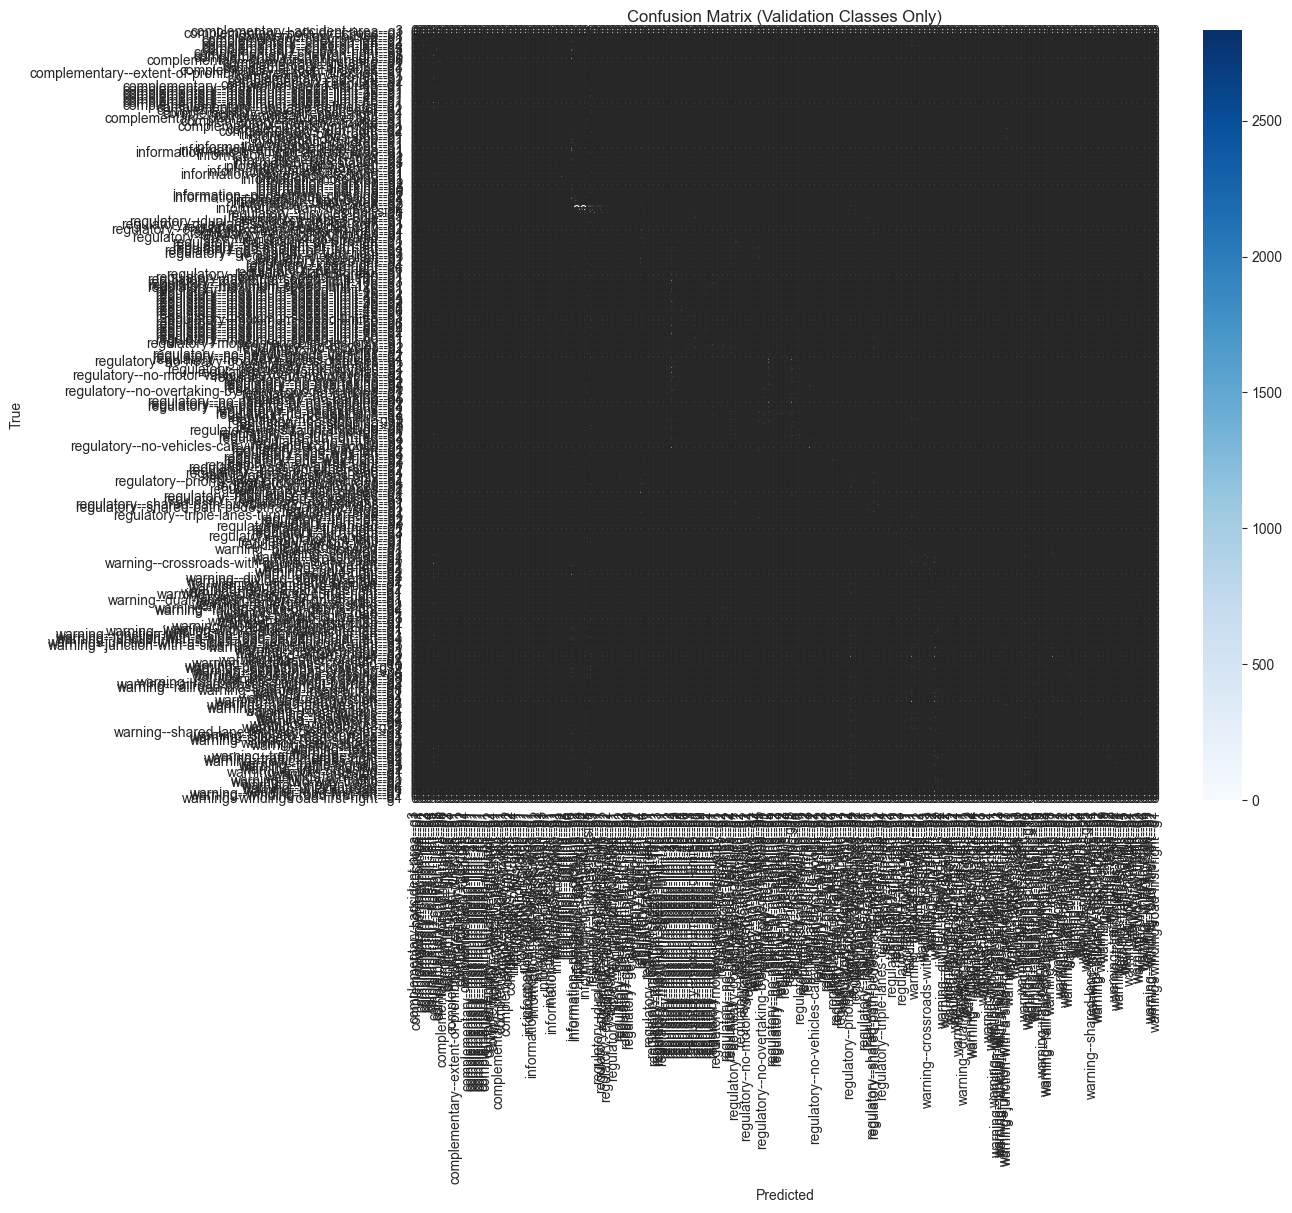

In [20]:
# -----------------------------
# Imports
# -----------------------------
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Paths
# -----------------------------
val_dir = "crops_per_label_val"                # validation crops folder
model_weights_path = "street_sign_classifier_weights.pth"
class_names_path = "class_names.pth"          # saved training class order

# -----------------------------
# Load class names from training
# -----------------------------
class_names = torch.load(class_names_path)
num_classes = len(class_names)
#print("Classes:", class_names)

# -----------------------------
# Data transforms
# -----------------------------
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# -----------------------------
# Load validation dataset
# -----------------------------
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

# Force class indices to match training
val_dataset.class_to_idx = {name: i for i, name in enumerate(class_names)}

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# -----------------------------
# Load model
# -----------------------------
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.load_state_dict(torch.load(model_weights_path))
model.eval()

# -----------------------------
# Run evaluation
# -----------------------------
all_labels = []
all_preds = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# -----------------------------
# Metrics
# -----------------------------
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# -----------------------------
# Per-class classification report
# -----------------------------
# Only include classes present in validation
unique_labels = np.unique(all_labels)
report = classification_report(
    all_labels,
    all_preds,
    labels=unique_labels,
    target_names=[class_names[i] for i in unique_labels],
    digits=4,
    zero_division=0
)
print("\nClassification Report:\n")
print(report)

# -----------------------------
# Confusion matrix
# -----------------------------
cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=[class_names[i] for i in unique_labels],
    yticklabels=[class_names[i] for i in unique_labels],
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation Classes Only)")
plt.show()
